# Data Screening


In [ ]:
 #Import Library

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Import Data
path = '/content/gym_members_exercise_tracking.csv'
df = pd.read_csv(path)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [ ]:
# Memastikan Data Tidak ada yang Kosong
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

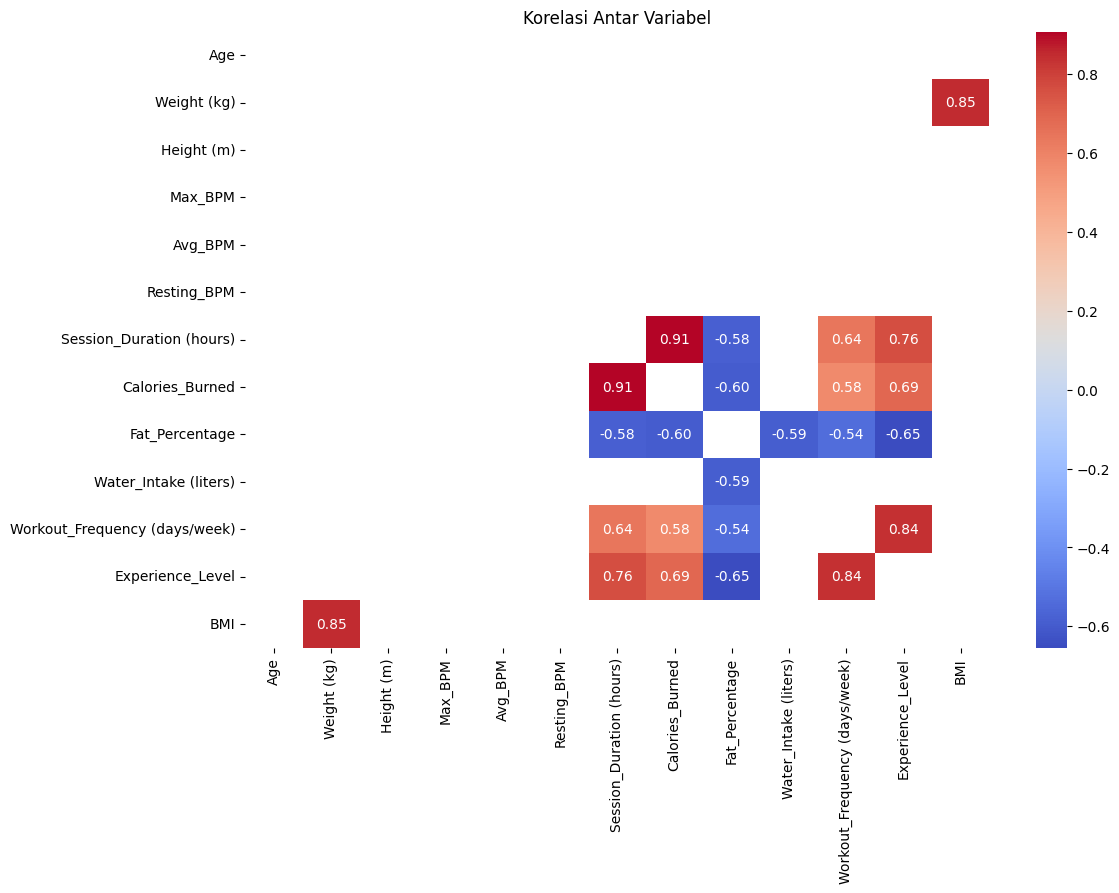

In [ ]:
# Membuat heatmap korelasi
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Menyaring korelasi kuat (0.5 sampai 1 dan -0.5 sampai -1)
strong_corr = correlation_matrix[(correlation_matrix >= 0.5) | (correlation_matrix <= -0.5)]
strong_corr = strong_corr.replace([1, -1], np.nan)  # Menghilangkan korelasi diri sendiri (1 atau -1)


plt.figure(figsize=(12, 8))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antar Variabel')
plt.show()

In [ ]:
# Mencari pasangan variabel dengan korelasi kuat
threshold = 0.5  # Batas korelasi kuat
strong_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        correlation_value = correlation_matrix.iloc[i, j]
        if abs(correlation_value) >= threshold:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            strong_pairs.append((var1, var2, correlation_value))

# Menampilkan pasangan variabel yang memiliki korelasi kuat
print("Pasangan variabel dengan korelasi kuat:")
for var1, var2, correlation_value in strong_pairs:
    print(f"{var1} dan {var2}: korelasi = {correlation_value:.2f}")


Pasangan variabel dengan korelasi kuat:
Weight (kg) dan BMI: korelasi = 0.85
Session_Duration (hours) dan Calories_Burned: korelasi = 0.91
Session_Duration (hours) dan Fat_Percentage: korelasi = -0.58
Session_Duration (hours) dan Workout_Frequency (days/week): korelasi = 0.64
Session_Duration (hours) dan Experience_Level: korelasi = 0.76
Calories_Burned dan Fat_Percentage: korelasi = -0.60
Calories_Burned dan Workout_Frequency (days/week): korelasi = 0.58
Calories_Burned dan Experience_Level: korelasi = 0.69
Fat_Percentage dan Water_Intake (liters): korelasi = -0.59
Fat_Percentage dan Workout_Frequency (days/week): korelasi = -0.54
Fat_Percentage dan Experience_Level: korelasi = -0.65
Workout_Frequency (days/week) dan Experience_Level: korelasi = 0.84


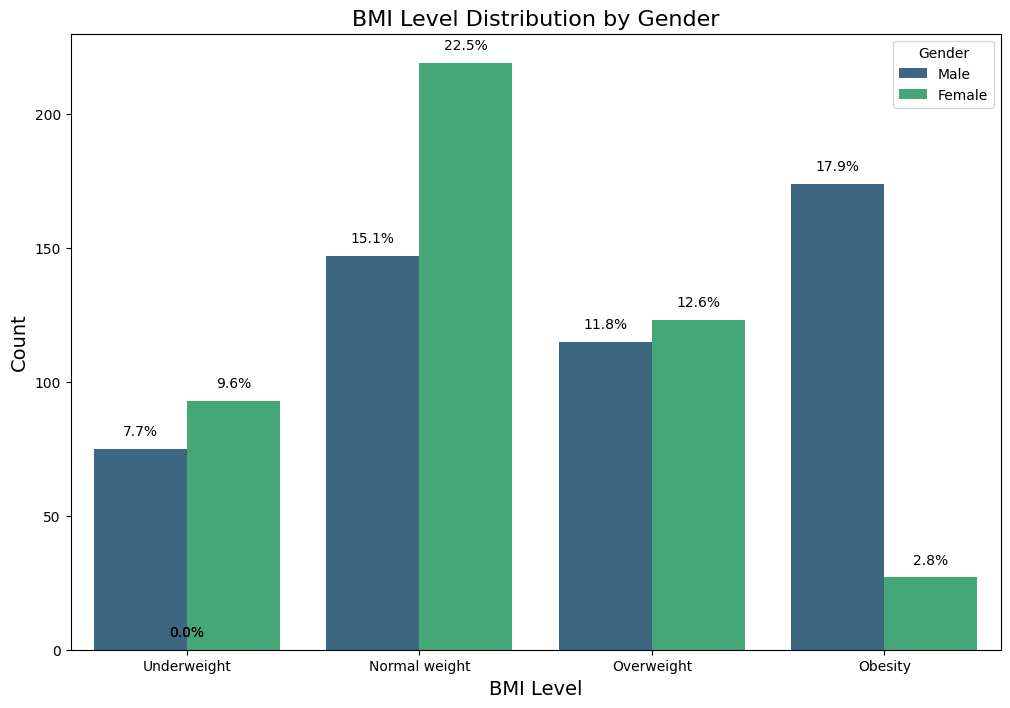

In [ ]:
# Definisikan fungsi untuk membuat kategori BMI_Level
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal weight'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obesity'

# Gunakan Fungsi untuk membuat kolom baru
df['BMI_Level'] = df['BMI'].apply(bmi_category)

# Kategorikan BMI Level
bmi_order = ['Underweight', 'Normal weight', 'Overweight', 'Obesity']

# Grafik
plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, x='BMI_Level', hue='Gender', palette='viridis', order=bmi_order)
plt.title("BMI Level Distribution by Gender", fontsize=16)
plt.xlabel("BMI Level", fontsize=14)
plt.ylabel("Count", fontsize=14)

# Tambahkan persentase pada grafik
for p in ax.patches:
    height = p.get_height()
    total = len(df)
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 5,
        f'{height / total * 100:.1f}%',
        ha='center',
        fontsize=10
    )

plt.legend(title='Gender')
plt.show()


Grafik ini menunjukkan distribusi tingkat BMI (Body Mass Index) berdasarkan gender. Dari data ini, kita bisa melihat bahwa perempuan memiliki persentase tertinggi pada kategori berat badan normal, yaitu sebesar 22,5%, sedangkan laki-laki hanya 15,1%. Hal ini menunjukkan bahwa lebih banyak perempuan berada dalam rentang BMI yang sehat dibandingkan laki-laki.

Pada kategori overweight, persentase perempuan sedikit lebih tinggi (12,6%) dibandingkan laki-laki (11,8%), menunjukkan bahwa kedua gender memiliki proporsi yang hampir seimbang dalam kategori ini. Sementara itu, kategori obesitas didominasi oleh laki-laki dengan persentase sebesar 17,9%, jauh lebih tinggi dibandingkan perempuan yang hanya 2,8%. Ini mengindikasikan bahwa obesitas lebih umum terjadi pada laki-laki dibandingkan perempuan.

Untuk kategori underweight, persentase perempuan lebih tinggi (9,6%) dibandingkan laki-laki (7,7%), menunjukkan bahwa underweight lebih banyak terjadi pada perempuan. Secara keseluruhan, grafik ini mengungkapkan perbedaan pola BMI antara laki-laki dan perempuan, di mana perempuan cenderung lebih banyak berada dalam rentang BMI normal, sedangkan laki-laki lebih banyak di kategori obesitas.

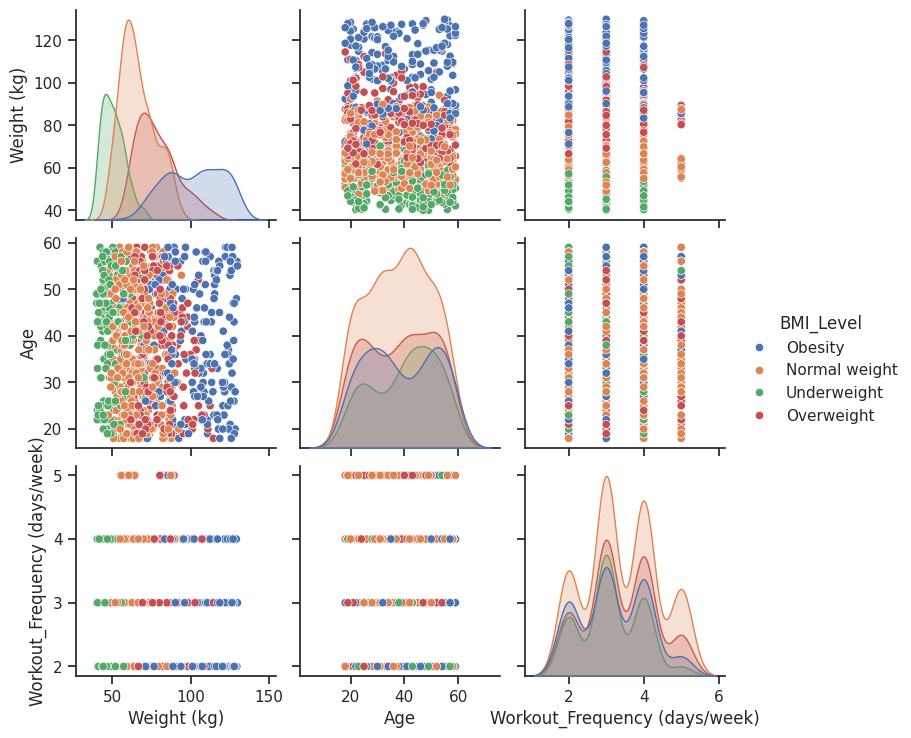

In [ ]:
# analisis multivariat pada dataset gym member exercise tracking
sns.set(style="ticks", color_codes=True)
sns.pairplot(df,vars = [ 'Weight (kg)','Age','Workout_Frequency (days/week)'],
hue="BMI_Level")
plt.show()

Grafik ini menunjukkan hubungan antara beberapa variabel (berat badan, usia, dan frekuensi latihan) dengan kategori BMI (Obesitas, Berat Normal, Kekurangan Berat, dan Kelebihan Berat). Berikut adalah beberapa insight yang dapat diambil:

1. Weight vs BMI Level: Dari grafik distribusi berat badan, terlihat bahwa individu yang memiliki BMI obesitas cenderung memiliki berat badan lebih tinggi dibandingkan kategori lainnya. Sebaliknya, kategori underweight memiliki distribusi berat yang lebih rendah. Kategori normal weight dan overweight berada di antara kedua kategori ekstrem tersebut.

2. Age vs BMI Level: Pada grafik yang menghubungkan usia dengan tingkat BMI, tidak ada perbedaan usia yang signifikan di antara kategori BMI. Semua kategori BMI terlihat tersebar merata pada rentang usia 20 hingga 60 tahun, menunjukkan bahwa BMI tidak terlalu berkaitan dengan usia dalam data ini.

3. Workout Frequency vs BMI Level: Frekuensi latihan tidak memperlihatkan perbedaan yang sangat jelas antar kategori BMI. Namun, terlihat bahwa sebagian besar individu dalam semua kategori melakukan latihan antara 2 hingga 5 kali per minggu. Tidak ada hubungan yang jelas antara frekuensi latihan dengan tingkat BMI tertentu.

Secara keseluruhan, grafik ini menunjukkan bahwa berat badan berhubungan dengan kategori BMI, sedangkan usia dan frekuensi latihan tidak menunjukkan pola yang jelas terkait BMI. Insight ini dapat membantu memahami faktor-faktor yang memengaruhi distribusi BMI dalam populasi ini.

<Figure size 1200x800 with 0 Axes>

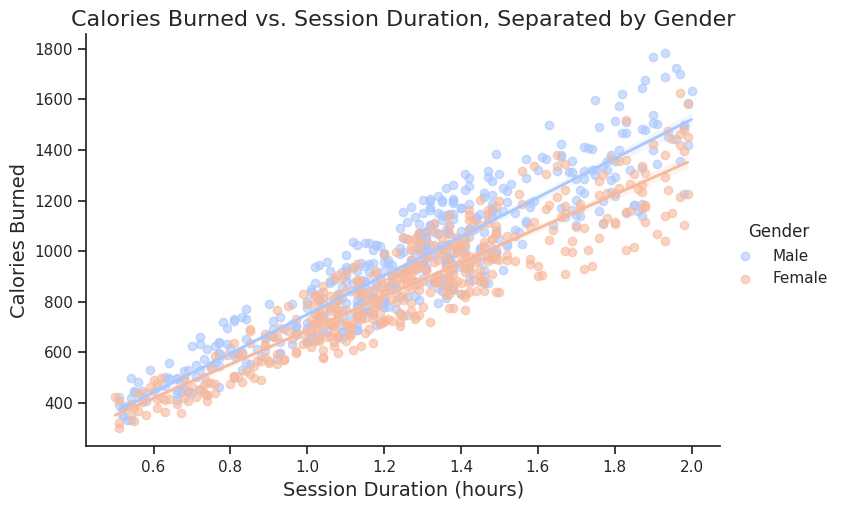

In [ ]:
# Scatter plot Calories Burned vs Session Duration
plt.figure(figsize=(12, 8))
sns.lmplot(data=df, x='Session_Duration (hours)', y='Calories_Burned', hue='Gender', aspect=1.5,
           scatter_kws={'alpha':0.6}, line_kws={'lw':2}, palette='coolwarm')
plt.title("Calories Burned vs. Session Duration, Separated by Gender", fontsize=16)
plt.xlabel("Session Duration (hours)", fontsize=14)
plt.ylabel("Calories Burned", fontsize=14)
plt.show()

Grafik ini menunjukkan korelasi positif antara durasi sesi latihan dan jumlah kalori yang terbakar, dengan perbedaan antara gender. Semakin lama seseorang berolahraga, semakin banyak kalori yang mereka bakar, yang berlaku untuk baik laki-laki maupun perempuan.

Namun, ada perbedaan yang konsisten antara laki-laki dan perempuan dalam jumlah kalori yang terbakar pada durasi yang sama. Pada setiap titik durasi latihan, laki-laki cenderung membakar lebih banyak kalori dibandingkan perempuan. Hal ini terlihat dari garis tren laki-laki yang berada sedikit lebih tinggi daripada garis tren perempuan.

Insight ini menunjukkan bahwa durasi latihan sangat memengaruhi jumlah kalori yang dibakar, tetapi faktor gender juga memiliki pengaruh yang signifikan. Artinya, meskipun waktu latihan sama, jumlah kalori yang terbakar dapat berbeda berdasarkan gender, di mana laki-laki cenderung membakar lebih banyak kalori dibandingkan perempuan. Insight ini dapat membantu dalam merancang program latihan yang lebih personal dan efektif berdasarkan target kalori dan pertimbangan gender.

<Figure size 1200x800 with 0 Axes>

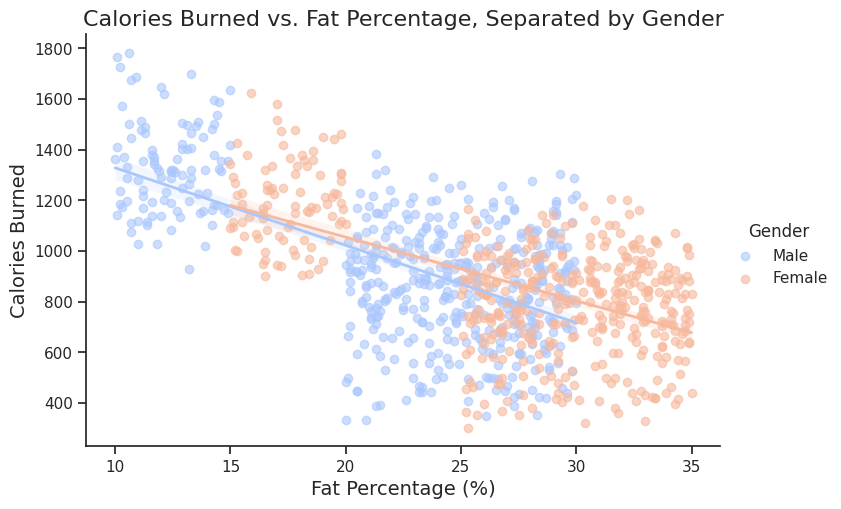

In [ ]:
# Scatter plot Calories Burned vs fat percentage
plt.figure(figsize=(12, 8))
sns.lmplot(data=df, x='Fat_Percentage', y='Calories_Burned', hue='Gender', aspect=1.5,
           scatter_kws={'alpha':0.6}, line_kws={'lw':2}, palette='coolwarm')
plt.title("Calories Burned vs. Fat Percentage, Separated by Gender", fontsize=16)
plt.xlabel("Fat Percentage (%)", fontsize=14)
plt.ylabel("Calories Burned", fontsize=14)
plt.show()


Grafik ini menunjukkan hubungan antara jumlah kalori yang dibakar dan persentase lemak dalam tubuh, yang dipisahkan berdasarkan jenis kelamin. Sumbu horizontal (x) menunjukkan persentase lemak tubuh, sementara sumbu vertikal (y) menunjukkan jumlah kalori yang dibakar. Warna biru mewakili data untuk laki-laki, dan warna merah muda untuk perempuan.

Dari grafik ini terlihat adanya korelasi negatif antara persentase lemak tubuh dan kalori yang dibakar, artinya semakin tinggi persentase lemak dalam tubuh, semakin rendah jumlah kalori yang dibakar. Meskipun demikian, kita juga bisa melihat perbedaan antara laki-laki dan perempuan. Laki-laki (titik biru) cenderung membakar lebih banyak kalori dibandingkan perempuan (titik merah muda) pada berbagai level persentase lemak tubuh.

<ipython-input-12-d08814b57424>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  x = sns.distplot(df['Age'].dropna())


<Axes: xlabel='Age', ylabel='Density'>

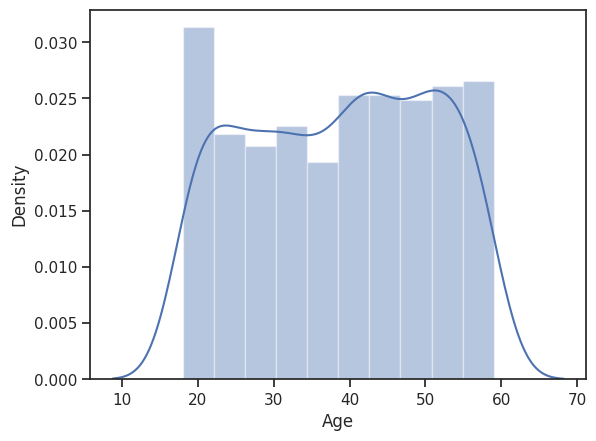

In [ ]:
x = sns.distplot(df['Age'].dropna())
x

# SUNNAH


In [ ]:
# Mengubah variabel kategorikal menjadi numerik (label encoding)
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_workout_type = LabelEncoder()
df['Workout_Type'] = le_workout_type.fit_transform(df['Workout_Type'])

# Lanjutkan dengan analisis Anda menggunakan df yang sudah diperbarui
df.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,BMI_Level
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20,Obesity
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00,Obesity
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71,Normal weight


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA

# Memilih variabel dependen dan independen untuk MANOVA
dependent_vars = ['Max_BPM', 'Avg_BPM', 'Resting_BPM']
independent_vars = ['Workout_Type', 'Experience_Level']

# Membangun model MANOVA
model = MANOVA.from_formula(
    f"{' + '.join(dependent_vars)} ~ {' + '.join(independent_vars)}", data=df)

# Menampilkan hasil MANOVA
print(model.mv_test())

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value   Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0202 3.0000 968.0000 15673.5380 0.0000
         Pillai's trace  0.9798 3.0000 968.0000 15673.5380 0.0000
 Hotelling-Lawley trace 48.5750 3.0000 968.0000 15673.5380 0.0000
    Roy's greatest root 48.5750 3.0000 968.0000 15673.5380 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
          Workout_Type      Value  Num DF  Den DF  F Value Pr > F
-----------------------------------------------------------------
              Wilks' lambda 0.9997 3.0000 968.0000  0.0914 0.9648
             Pillai's trace 0.

Hasil MANOVA menunjukkan bahwa terdapat perbedaan signifikan dalam Max_BPM, Avg_BPM, dan Resting_BPM antara kelompok yang berbeda berdasarkan Workout_Type dan Experience_Level. Ini menunjukkan bahwa jenis latihan dan tingkat pengalaman memengaruhi detak jantung selama berolahraga.

Mean Squared Error: 15280.327148542558
R-squared: 0.8168376092050225
Koefisien Model:
Session_Duration (hours): 717.8652178013427
Workout_Frequency (days/week): -6.694043714198255
Experience_Level: 10.806538971035229
                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     1235.
Date:                Thu, 07 Nov 2024   Prob (F-statistic):          1.79e-294
Time:                        07:50:57   Log-Likelihood:                -4771.5
No. Observations:                 778   AIC:                             9551.
Df Residuals:                     774   BIC:                             9570.
Df Model:                           3                                         
Covariance Type:            nonrobust                                   

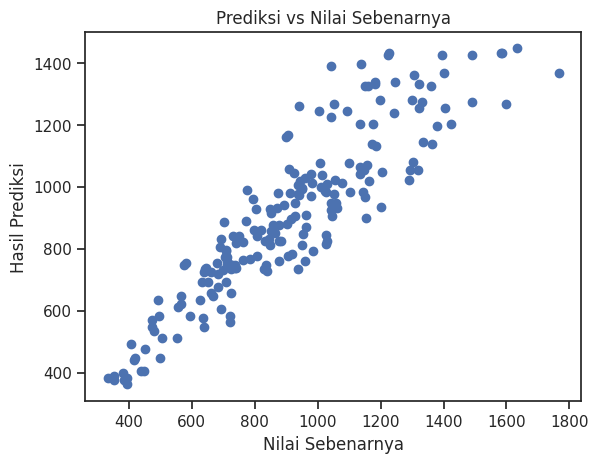

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Memilih variabel independen dan dependen untuk regresi linear berganda
X = df[['Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Experience_Level']]
y = df['Calories_Burned']

# Membagi data menjadi data pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model regresi linear berganda
model = LinearRegression()

# Melatih model dengan data pelatihan
model.fit(X_train, y_train)

# Memprediksi dengan data pengujian
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Menampilkan koefisien model
print("Koefisien Model:")
for i, coef in enumerate(model.coef_):
  print(f"{X.columns[i]}: {coef}")

# Membuat model regresi linear berganda menggunakan statsmodels untuk melihat p-value
X_train_sm = sm.add_constant(X_train)  # Menambahkan konstanta (intercept)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

# Plot hasil prediksi vs nilai sebenarnya
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Sebenarnya")
plt.ylabel("Hasil Prediksi")
plt.title("Prediksi vs Nilai Sebenarnya")
plt.show()

Linear Regression: Model regresi linear untuk memprediksi Calories_Burned memiliki R-squared yang relatif tinggi, menunjukkan bahwa model tersebut cukup baik dalam memprediksi jumlah kalori yang terbakar berdasarkan Session_Duration (hours), Workout_Frequency (days/week), dan Experience_Level.

In [ ]:

# Memilih variabel independen dan dependen untuk regresi logistik
X = df[['Weight (kg)', 'Height (m)', 'Water_Intake (liters)']]
y = df['Gender']

# Membagi data menjadi data pelatihan dan pengujian
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model regresi logistik
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

# Melatih model dengan data pelatihan
model.fit(X_train, y_train)

# Memprediksi dengan data pengujian
y_pred = model.predict(X_test)

# Evaluasi model
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy}")
print(classification_report(y_test, y_pred))

# Menampilkan koefisien model
print("Koefisien Model:")
for i, coef in enumerate(model.coef_[0]):
  print(f"{X.columns[i]}: {coef}")


Akurasi Model: 0.9076923076923077
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        98
           1       0.94      0.87      0.90        97

    accuracy                           0.91       195
   macro avg       0.91      0.91      0.91       195
weighted avg       0.91      0.91      0.91       195

Koefisien Model:
Weight (kg): 0.07403723566418684
Height (m): 5.347915135646583
Water_Intake (liters): 3.2481005728964707


Logistic Regression: Model regresi logistik untuk memprediksi Gender memiliki akurasi yang cukup tinggi. Ini menunjukkan bahwa model tersebut dapat memprediksi gender seseorang dengan cukup baik berdasarkan Weight (kg), Height (m), dan Water_Intake (liters).